# Figure 7 — Raw cross-survey agreement (bright vs all)

**Left:** per-band 2D offset-cloud contours of Rubin/NISP $-$ Euclid VIS, pooled over all tiles;
**solid = all detections, dashed = bright (S/N \u2265 30)**. Each band is de-meaned (the few-mas
systematic frame/registration offset is removed and is quantified separately in the concordance
section), so the contours isolate per-source scatter. Bright sources already agree near the
concordance floor; the full population is 4\u20135\u00d7 wider.
**Right:** radial-offset median vs measured S/N, per band \u2014 the continuous FWHM/SNR degradation.

Self-contained: reads the latent-position anchor cache directly. Data are **Q1** (production
detector `centernet_vis_sep`). Both panels are head-independent (classical per-band centroids vs
VIS), so this renders from the raw-only cache now; it auto-upgrades to the full eval cache (identical
raw columns) once the latent-position head finishes training.

In [1]:
import sys
from pathlib import Path
import numpy as np

def find_repo_root(s=None):
    s=(s or Path.cwd()).resolve()
    for c in [s,*s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError('repo root')
REPO=find_repo_root(); NB=Path.cwd()
OUT=REPO/'paper'/'figures'/'fig7_astrometry_agreement.png'

CANDIDATES=[
    # Q1 (production): full eval cache once the head finishes (same raw cols), else the
    # head-independent raw-only cache produced now by export_raw_anchors.py.
    REPO/'models/checkpoints/latent_position_q1_vissep/anchors_centernet_q1_vissep_dedup.npz',
    REPO/'models/checkpoints/latent_position_q1_vissep/anchors_centernet_q1_vissep.npz',
    REPO/'models/checkpoints/latent_position_q1_vissep/anchors_q1_vissep_raw.npz',
]
CACHE=next((p for p in CANDIDATES if p.exists()), None)
assert CACHE is not None, 'no anchor cache found'
print('anchor cache:', CACHE.relative_to(REPO), '| raw-only:', 'raw' in CACHE.name)

# --- knobs ---
BRIGHT_SNR    = 30       # 'bright' = S/N >= this
ENCLOSED_FRAC = 0.50     # contour encloses this fraction => ring radius = median radial offset
DROP_BANDS    = ['u','y']  # skip CONTOUR for these (too large/noisy); still in legend + S/N panel
DEMEAN        = False    # keep the systematic offset visible (it IS the concordance we measure)
VIEW          = 90       # left-panel axis half-range [mas]
MIN_N_BIN     = 100      # right panel: min sources per S/N bin (else drop; kills sparse-bin noise)


anchor cache: models/checkpoints/latent_position_q1_vissep/anchors_centernet_q1_vissep_dedup.npz | raw-only: False


enclosed-fraction check (should be ~0.50): [0.5  0.5  0.5  0.5  0.5  0.51 0.5  0.51 0.5  0.5  0.5  0.5  0.5  0.5 ]


saved paper/figures/fig7_astrometry_agreement.png


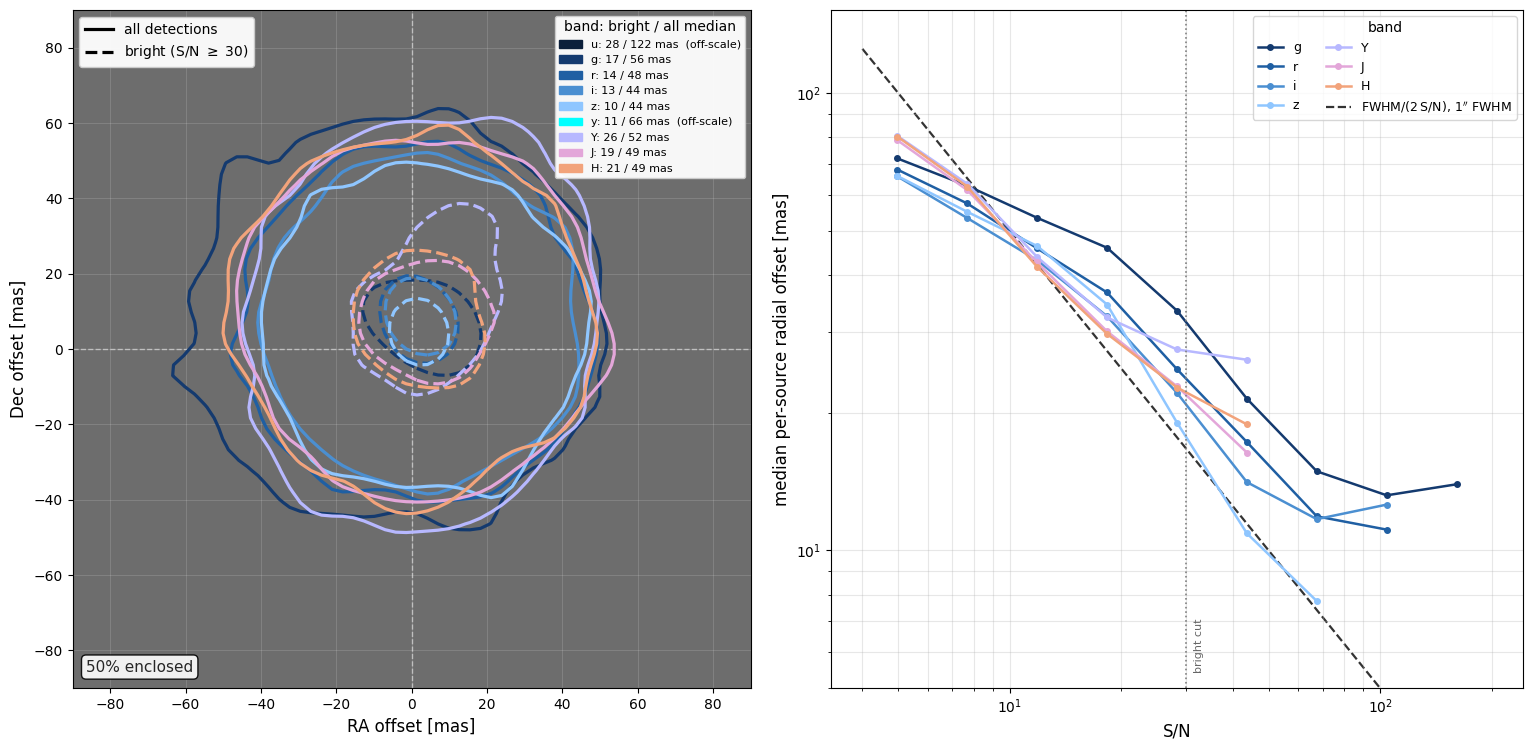

In [2]:
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter

d=np.load(CACHE, allow_pickle=True)
BAND_DEF=[('u','#0B1F3A'),('g','#143A6F'),('r','#1F5FA3'),('i','#4B8FD1'),('z','#8FC6FF'),
          ('y','#00FFFF'),('nisp_Y','#B7B8FF'),('nisp_J','#E3A6D9'),('nisp_H','#F2A37B')]
LAB={'nisp_Y':'Y','nisp_J':'J','nisp_H':'H'}
CONTOUR_SKIP=DROP_BANDS
BINS=64; SMOOTH=2.0   # light smoothing: shapes the curve only; enclosed fraction is calibrated on points

def offsets(b,snr_min):
    raw=np.asarray(d[f'{b}_raw'])*1000.0; snr=np.asarray(d[f'{b}_snr'])
    m=snr>=snr_min if snr_min else np.ones(len(snr),bool)
    dra,ddec=raw[m,0].copy(),raw[m,1].copy()
    if DEMEAN and len(dra):
        dra-=np.median(raw[:,0]); ddec-=np.median(raw[:,1])
    return dra,ddec

def draw_point_frac_contour(ax,dra,ddec,col,ls,frac):
    """Contour enclosing exactly `frac` of the POINTS (highest-density region)."""
    if len(dra)<80: return np.nan
    H,xe,ye=np.histogram2d(dra,ddec,bins=BINS,range=[[-VIEW,VIEW],[-VIEW,VIEW]])
    Hs=gaussian_filter(H.T,SMOOTH)                       # [iy,ix]
    ix=np.clip(np.digitize(dra,xe)-1,0,BINS-1)
    iy=np.clip(np.digitize(ddec,ye)-1,0,BINS-1)
    dens=Hs[iy,ix]
    lvl=np.quantile(dens,1.0-frac)                       # frac of points have density >= lvl
    xc=0.5*(xe[:-1]+xe[1:]);yc=0.5*(ye[:-1]+ye[1:]);X,Y=np.meshgrid(xc,yc)
    ax.contour(X,Y,Hs,levels=[lvl],colors=col,linewidths=2.3,linestyles=ls)
    return (dens>=lvl).mean()                            # actual enclosed fraction (sanity)

fig,(axL,axR)=plt.subplots(1,2,figsize=(15.5,7.6))

# ---- Left: 50%-of-points contours (real shape). solid=all, dashed=bright ----
axL.set_facecolor('#6D6D6D'); axL.set_xlim(-VIEW,VIEW); axL.set_ylim(-VIEW,VIEW); axL.set_aspect('equal')
axL.grid(True,alpha=0.2,color='white',lw=0.5)
axL.axhline(0,color='white',ls='--',alpha=0.5,lw=1); axL.axvline(0,color='white',ls='--',alpha=0.5,lw=1)
band_handles=[]; encl=[]
for b,col in BAND_DEF:
    da,ea=offsets(b,0); db,eb=offsets(b,BRIGHT_SNR)
    r_all=np.median(np.hypot(da,ea)) if len(da) else np.nan
    r_br =np.median(np.hypot(db,eb)) if len(db) else np.nan
    if b not in CONTOUR_SKIP:
        f1=draw_point_frac_contour(axL,da,ea,col,'solid',ENCLOSED_FRAC)
        f2=draw_point_frac_contour(axL,db,eb,col,'dashed',ENCLOSED_FRAC)
        encl+=[f1,f2]
        lab=f"{LAB.get(b,b)}: {r_br:.0f} / {r_all:.0f} mas"
    else:
        lab=f"{LAB.get(b,b)}: {r_br:.0f} / {r_all:.0f} mas  (off-scale)"
    band_handles.append(mpatches.Patch(color=col,label=lab))
print("enclosed-fraction check (should be ~%.2f):"%ENCLOSED_FRAC, np.round([e for e in encl if np.isfinite(e)],2))
axL.set_xlabel('RA offset [mas]',fontsize=12)
axL.set_ylabel('Dec offset [mas]',fontsize=12)
style_handles=[Line2D([0],[0],color='k',ls='solid',lw=2.3,label='all detections'),
               Line2D([0],[0],color='k',ls='--',lw=2.3,label=f'bright (S/N $\\geq$ {BRIGHT_SNR})')]
leg1=axL.legend(handles=style_handles,loc='upper left',fontsize=10,framealpha=0.95,facecolor='white'); axL.add_artist(leg1)
axL.legend(handles=band_handles,loc='upper right',fontsize=8.0,framealpha=0.95,facecolor='white',ncol=1,title='band: bright / all median')
axL.text(0.02,0.02,f'{int(ENCLOSED_FRAC*100)}% enclosed',transform=axL.transAxes,fontsize=11,color='0.15',va='bottom',ha='left',bbox=dict(boxstyle='round',facecolor='white',alpha=0.9))

# ---- Right: radial median vs S/N, clean bands only, log-log ----
edges=np.logspace(np.log10(4),np.log10(200),10); cen=np.sqrt(edges[:-1]*edges[1:])
for b,col in BAND_DEF:
    if b in CONTOUR_SKIP: continue
    raw=np.asarray(d[f'{b}_raw'])*1000.0; snr=np.asarray(d[f'{b}_snr'])
    if DEMEAN: raw=raw-np.median(raw,axis=0)
    rad=np.hypot(raw[:,0],raw[:,1])
    yv=[np.median(rad[(snr>=lo)&(snr<hi)]) if ((snr>=lo)&(snr<hi)).sum()>=MIN_N_BIN else np.nan
        for lo,hi in zip(edges[:-1],edges[1:])]
    axR.plot(cen,yv,'-o',color=col,ms=4,lw=1.8,label=LAB.get(b,b))

# ---- King (1983) photon-noise guide ----
# Per-axis centroid error ~ (FWHM/2.355)/sqrt(N); photon-limited S/N ~ sqrt(N);
# median radial offset of a 2D Gaussian = 1.177 sigma  =>  r_med ~ FWHM/(2 S/N).
KING_FWHM_MAS = 1000.0   # representative Rubin median seeing (~1")
snr_g = np.logspace(np.log10(4), np.log10(200), 60)
axR.plot(snr_g, KING_FWHM_MAS/(2.0*snr_g), color='0.2', ls='--', lw=1.6, zorder=1,
         label=r"FWHM/(2$\,$S/N), 1$^{\prime\prime}$ FWHM")

axR.set_xscale('log'); axR.set_yscale('log')
axR.set_ylim(bottom=5)
axR.set_xlabel('S/N',fontsize=12); axR.set_ylabel('median per-source radial offset [mas]',fontsize=12)
axR.axvline(BRIGHT_SNR,color='0.5',ls=':',lw=1.2); axR.text(BRIGHT_SNR*1.05,5.4,'bright cut',rotation=90,color='0.4',fontsize=8,va='bottom')
axR.grid(True,alpha=0.3,which='both'); axR.legend(fontsize=9,ncol=2,title='band')

plt.tight_layout()
OUT.parent.mkdir(parents=True,exist_ok=True)
fig.savefig(OUT,dpi=200,bbox_inches='tight')
print('saved',OUT.relative_to(REPO)); plt.show()

In [3]:
# per-band summary: signed systematic + radial median, bright vs all
print(f"{'band':5} | {'sys dRA*':>8} {'sys dDec':>8} | {'bright |r|':>9} {'Nb':>6} | {'all |r|':>8} {'Na':>7}")
print('-'*62)
for b,_ in BAND_DEF:
    raw=np.asarray(d[f'{b}_raw'])*1000; snr=np.asarray(d[f'{b}_snr'])
    sra,sde=np.median(raw[:,0]),np.median(raw[:,1])
    mb=snr>=BRIGHT_SNR
    rb=np.median(np.hypot(raw[mb,0]-sra,raw[mb,1]-sde))
    ra=np.median(np.hypot(raw[:,0]-sra,raw[:,1]-sde))
    flag=' (dropped)' if b in DROP_BANDS else ''
    print(f"{LAB.get(b,b):5} | {sra:8.1f} {sde:8.1f} | {rb:9.1f} {mb.sum():6d} | {ra:8.1f} {len(snr):7d}{flag}")


band  | sys dRA* sys dDec | bright |r|     Nb |  all |r|      Na
--------------------------------------------------------------
u     |     -2.7     10.5 |      18.7    133 |    122.3    3628 (dropped)
g     |     -2.4      7.8 |      15.6   1171 |     55.5   17626
r     |      1.5      6.3 |      11.5   1820 |     47.5   20624
i     |      1.8      7.0 |      10.1   1927 |     43.3   18270
z     |      2.5      4.8 |       8.4   1437 |     43.8   12622
y     |     -0.7      7.2 |       7.9    483 |     66.2    5059 (dropped)
Y     |      3.1      6.7 |      23.0    316 |     51.6   23386
J     |      3.0      7.1 |      16.8    441 |     48.3   26762
H     |      0.6      7.5 |      18.2    441 |     48.3   26047
